In [1]:
# Imports & Download Data
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import tensorflow as tf
from tensorflow.keras.utils import image_dataset_from_directory
from sklearn.metrics import confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

# Download dataset using kagglehub
import kagglehub
path = kagglehub.dataset_download("anirudhcv/labeled-optical-coherence-tomography-oct")
print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/anirudhcv/labeled-optical-coherence-tomography-oct


In [2]:
#Load the Dataset
# IMPORTANT: Pointing to the correct 'train' and 'val' directories
train_data_dir = os.path.join(path, "Dataset - train+val+test/train")
val_data_dir = os.path.join(path, "Dataset - train+val+test/val")

training_set = image_dataset_from_directory(
    train_data_dir,
    labels="inferred",
    label_mode="int",
    color_mode="rgb",
    batch_size=32,
    image_size=(224, 224),
    shuffle=True,
)

validation_set = image_dataset_from_directory(
    val_data_dir,
    labels="inferred",
    label_mode="int",
    color_mode="rgb",
    batch_size=32,
    image_size=(224, 224),
    shuffle=False, # No need to shuffle validation set
)

print("Training classes:", training_set.class_names)
print("Validation classes:", validation_set.class_names)

Found 76515 files belonging to 4 classes.


I0000 00:00:1789232860.817111      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 21861 files belonging to 4 classes.
Training classes: ['CNV', 'DME', 'DRUSEN', 'NORMAL']
Validation classes: ['CNV', 'DME', 'DRUSEN', 'NORMAL']


In [3]:
#Apply One-Hot Encoding and Data Augmentation
num_classes = 4 

# 1. Data Augmentation Pipeline (applied ONLY to training data)
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2),
    tf.keras.layers.RandomBrightness(0.2),
])

def one_hot_encode_labels(image, label):
    return image, tf.one_hot(label, num_classes)

def augment_images(image, label):
    # training=True ensures the augmentation is active only during training
    return data_augmentation(image, training=True), label

# 2. One-hot encode both datasets
training_set_one_hot = training_set.map(one_hot_encode_labels)
validation_set_one_hot = validation_set.map(one_hot_encode_labels)

# 3. Apply augmentation ONLY to the training set
training_set_augmented = training_set_one_hot.map(augment_images)

print("Datasets are prepared with one-hot encoding and augmentation!")

Datasets are prepared with one-hot encoding and augmentation!


In [4]:
#Build the Model
INPUT_SHAPE = (224, 224, 3)

mobNet = tf.keras.applications.MobileNetV3Large(
    input_shape=INPUT_SHAPE,
    alpha=1.0,
    minimalistic=False,
    include_top=False,
    weights="imagenet",
    pooling=None,
    include_preprocessing=True,
    name="MobileNetV3Large",
)

model = tf.keras.Sequential([
    mobNet,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(units=4, activation='softmax')
])

12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
#Define Focal Loss and Compile
@tf.keras.utils.register_keras_serializable()
class CategoricalFocalLoss(tf.keras.losses.Loss):
    def __init__(self, gamma=2.0, name="categorical_focal_loss", **kwargs):
        super().__init__(name=name, **kwargs)
        self.gamma = gamma

    def call(self, y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, tf.keras.backend.epsilon(), 1. - tf.keras.backend.epsilon())
        p_t = tf.reduce_sum(y_true * y_pred, axis=-1, keepdims=True)
        focal_weight = tf.pow(1. - p_t, self.gamma)
        ce = -y_true * tf.math.log(y_pred)
        return tf.reduce_mean(tf.reduce_sum(focal_weight * ce, axis=-1))

    def get_config(self):
        config = super().get_config()
        config.update({"gamma": self.gamma})
        return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)

focal_loss_fn = CategoricalFocalLoss(gamma=2.0)
metrics_list = ["accuracy", tf.keras.metrics.F1Score()]

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss=focal_loss_fn,
    metrics=metrics_list
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ MobileNetV3Large (Functional)   │ (None, 7, 7, 960)      │     2,996,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 960)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         3,844 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,000,196 (11.44 MB)

 Trainable params: 2,975,796 (11.35 MB)

 Non-trainable params: 24,400 (95.31 KB)

In [6]:
#Train the Model (with Callbacks)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks = [
    # Stop training if val_loss doesn't improve for 3 epochs
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    # Save the best model directly to Kaggle's working directory after every epoch
    ModelCheckpoint(
        filepath='/kaggle/working/best_model_augmented_focal.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

training_history = model.fit(
    x=training_set_augmented,       # <--- Using augmented training data
    validation_data=validation_set_one_hot,
    epochs=15,
    callbacks=callbacks
)

Epoch 1/15


2026-09-12 17:12:32.816077: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-12 17:12:33.000527: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-12 17:12:33.442769: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-12 17:12:33.639616: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1789233173.162510     149 device_compiler.h:196]

2391/2392 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step - accuracy: 0.8423 - f1_score: 0.7430 - loss: 0.2157

2026-09-12 17:31:18.260273: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-12 17:31:18.455790: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


2392/2392 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step - accuracy: 0.8423 - f1_score: 0.7430 - loss: 0.2157
Epoch 1: val_loss improved from None to 0.08441, saving model to /kaggle/working/best_model_augmented_focal.keras

Epoch 1: finished saving model to /kaggle/working/best_model_augmented_focal.keras
2392/2392 ━━━━━━━━━━━━━━━━━━━━ 1269s 504ms/step - accuracy: 0.9047 - f1_score: 0.8366 - loss: 0.1158 - val_accuracy: 0.9219 - val_f1_score: 0.8493 - val_loss: 0.0844
Epoch 2/15
2391/2392 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step - accuracy: 0.9425 - f1_score: 0.8994 - loss: 0.0629
Epoch 2: val_loss improved from 0.08441 to 0.05187, saving model to /kaggle/working/best_model_augmented_focal.keras

Epoch 2: finished saving model to /kaggle/working/best_model_augmented_focal.keras
2392/2392 ━━━━━━━━━━━━━━━━━━━━ 1091s 456ms/step - accuracy: 0.9453 - f1_score: 0.9039 - loss: 0.0576 - val_accuracy: 0.9521 - val_f1_score: 0.9165 - val_loss: 0.0519
Epoch 3/15
2391/2392 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step - accu

In [8]:
#Save History and Model to Kaggle Working Directory
# Save the final model
model.save("/kaggle/working/final_eye_disease_model.keras")

# Save the training history so you can plot it later
with open('/kaggle/working/training_history.pkl', 'wb') as f:
    pickle.dump(training_history.history, f)

print("Model and history saved to /kaggle/working/!")

Model and history saved to /kaggle/working/!


684/684 ━━━━━━━━━━━━━━━━━━━━ 36s 45ms/step


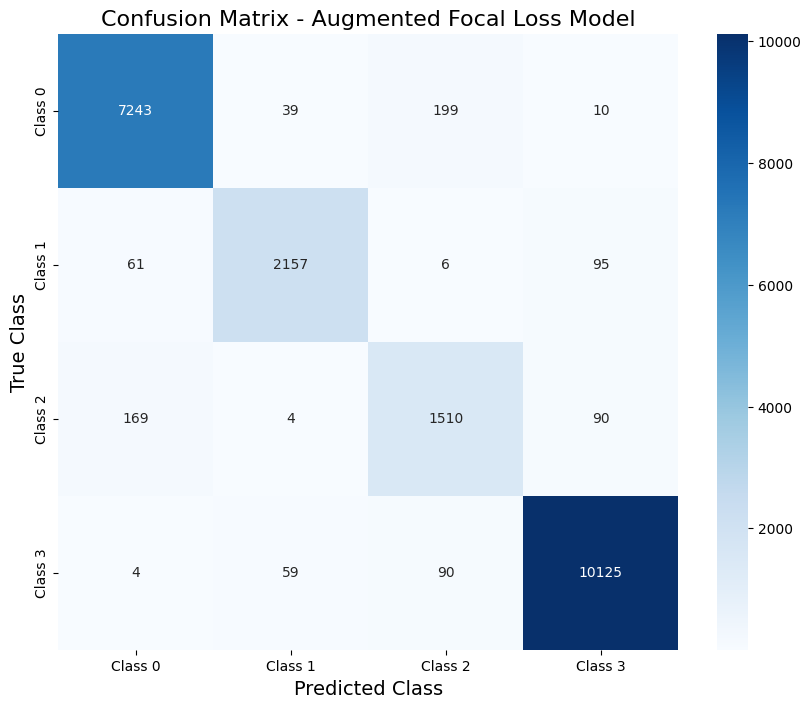

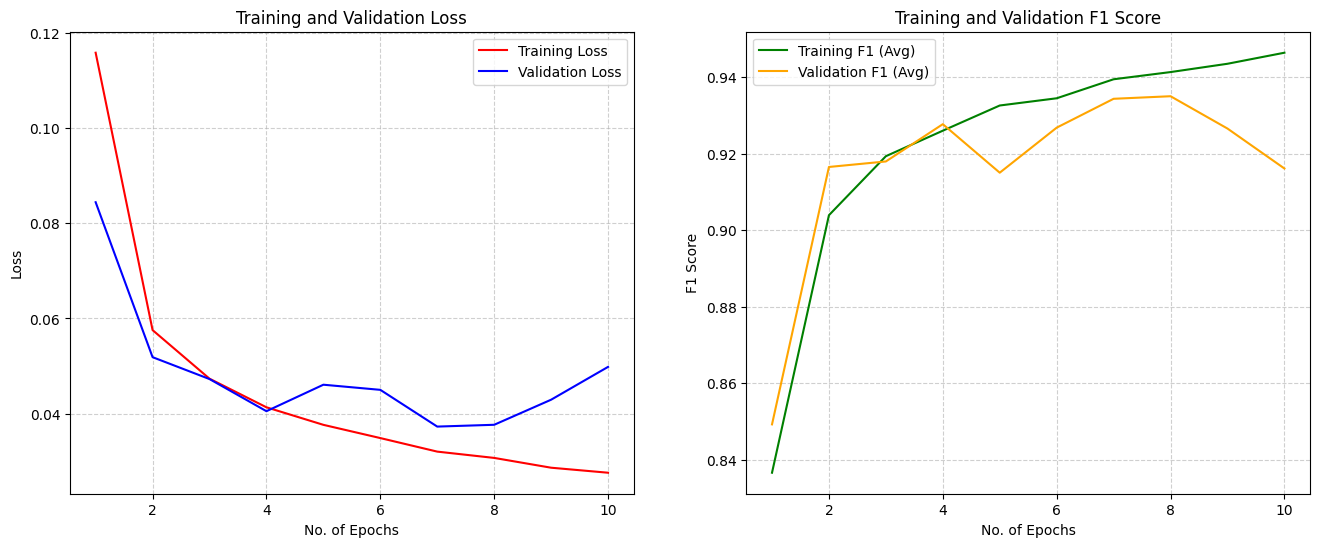

All graphs saved to /kaggle/working/!


In [9]:
 #Generate Confusion Matrix and Loss Graphs
# --- 1. Confusion Matrix ---
val_labels = np.concatenate([np.argmax(y.numpy(), axis=-1) for x, y in validation_set_one_hot], axis=0)
predictions = model.predict(validation_set_one_hot)
pred_labels = np.argmax(predictions, axis=-1)

cm = confusion_matrix(val_labels, pred_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Class 0', 'Class 1', 'Class 2', 'Class 3'],
            yticklabels=['Class 0', 'Class 1', 'Class 2', 'Class 3'])
plt.title('Confusion Matrix - Augmented Focal Loss Model', fontsize=16)
plt.ylabel('True Class', fontsize=14)
plt.xlabel('Predicted Class', fontsize=14)
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# --- 2. Loss and F1 Graph ---
history = training_history.history
epochs = range(1, len(history['loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Loss
ax1.plot(epochs, history['loss'], color='red', label='Training Loss')
ax1.plot(epochs, history['val_loss'], color='blue', label='Validation Loss')
ax1.set_xlabel("No. of Epochs")
ax1.set_ylabel("Loss")
ax1.set_title("Training and Validation Loss")
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# Plot 2: F1 Score (Average of 4 classes)
train_f1_avg = [np.mean(f1) for f1 in history['f1_score']]
val_f1_avg = [np.mean(f1) for f1 in history['val_f1_score']]
ax2.plot(epochs, train_f1_avg, color='green', label='Training F1 (Avg)')
ax2.plot(epochs, val_f1_avg, color='orange', label='Validation F1 (Avg)')
ax2.set_xlabel("No. of Epochs")
ax2.set_ylabel("F1 Score")
ax2.set_title("Training and Validation F1 Score")
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

plt.savefig('/kaggle/working/loss_f1_graph.png', dpi=300, bbox_inches='tight')
plt.show()

print("All graphs saved to /kaggle/working/!")